<a href="https://colab.research.google.com/github/Mokshagnatej/Internship-Innolift-Ventures/blob/main/Day_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anomaly Detection Model Comparison

In [46]:
import pandas as pd

df = pd.read_csv("/content/dataset.csv")

df.head()

,window_length,duration_minutes,sampling_interval_minutes,value_mean,value_std,value_min,value_max,value_median,value_q25,value_q75,...,value_first,value_last,value_trend,value_abs_diff_mean,value_abs_diff_std,value_max_jump,value_energy,peak_to_mean_ratio,source_file,anomaly
0,48,235.0,5.0,20.00,0.000000,20.0,20.00,20.0,20.0,20.00,...,20.0,20.00,0.000000,0.000000,0.000000,0.0,400.0000,1.00000,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
1,48,235.0,5.0,20.00,0.000000,20.0,20.00,20.0,20.0,20.00,...,20.0,20.00,0.000000,0.000000,0.000000,0.0,400.0000,1.00000,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
2,48,235.0,5.0,20.00,0.000000,20.0,20.00,20.0,20.0,20.00,...,20.0,20.00,0.000000,0.000000,0.000000,0.0,400.0000,1.00000,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
3,48,235.0,5.0,32.00,20.784610,20.0,68.00,20.0,20.0,32.00,...,20.0,68.00,1.125488,1.021277,6.926635,48.0,1456.0000,2.12500,artificialNoAnomaly/artificialNoAnomaly/art_da...,0
4,48,235.0,5.0,61.28,24.229305,20.0,79.52,72.8,56.0,78.08,...,20.0,79.52,1.470638,1.266383,7.032555,48.0,4342.2976,1.29765,artificialNoAnomaly/artificialNoAnomaly/art_da...,0


In [47]:
df.columns

Index(['window_length', 'duration_minutes', 'sampling_interval_minutes',
       'value_mean', 'value_std', 'value_min', 'value_max', 'value_median',
       'value_q25', 'value_q75', 'value_range', 'value_iqr', 'value_first',
       'value_last', 'value_trend', 'value_abs_diff_mean',
       'value_abs_diff_std', 'value_max_jump', 'value_energy',
       'peak_to_mean_ratio', 'source_file', 'anomaly'],
      dtype='object')

In [48]:
X = df.drop("anomaly", axis=1)
y = df["anomaly"]

print(X.shape)
print(y.shape)

(15192, 21)
(15192,)


In [49]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(15192, 77)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(12153, 77)
(3039, 77)


In [51]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [52]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.9443896018427114


In [53]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [54]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 1.0


In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [56]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [57]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [58]:
from sklearn.metrics import accuracy_score

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 1.0


In [59]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.655125,
        0.571975,
        0.649450,
        0.658075
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.655125
1,Decision Tree,0.571975
2,Random Forest,0.649450
3,Gradient Boosting,0.658075


In [60]:
comparison_df.to_csv("model_comparison.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, y_pred in models.items():
    results.append([
        model_name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.94439,0.891872,0.94439,0.91738
1,Decision Tree,1.00000,1.000000,1.00000,1.00000
2,Random Forest,1.00000,1.000000,1.00000,1.00000
3,Gradient Boosting,1.00000,1.000000,1.00000,1.00000


In [62]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Updated CSV saved")

Updated CSV saved


In [63]:
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

In [64]:
print(models["Logistic Regression"])

[1 1 1 ... 1 1 1]


In [65]:
type(models["Logistic Regression"])


numpy.ndarray

In [66]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["Logistic Regression"]))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       169
           1       0.94      1.00      0.97      2870

    accuracy                           0.94      3039
   macro avg       0.47      0.50      0.49      3039
weighted avg       0.89      0.94      0.92      3039



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


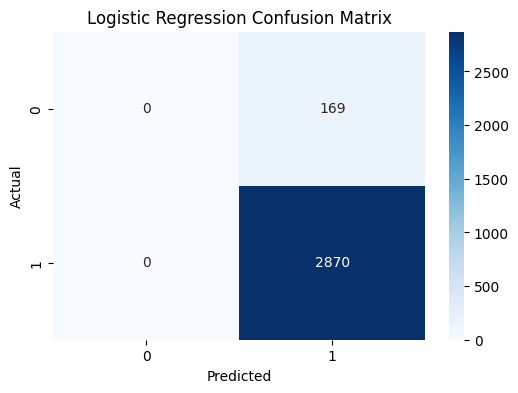

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

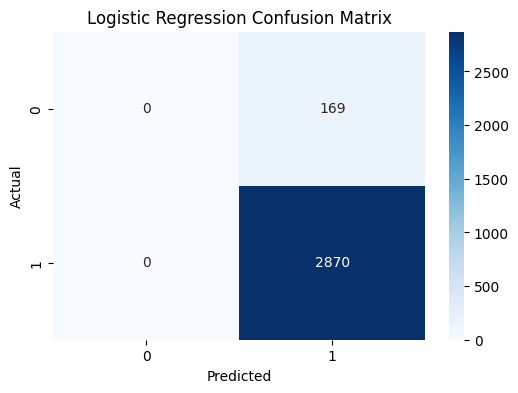

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

### Model 2 Confusion Matrix (Decision Tree)

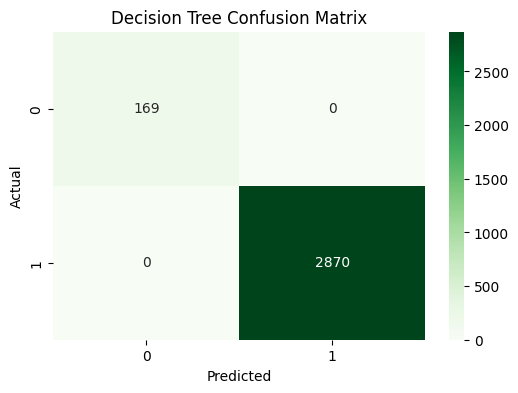

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.savefig("confusion_matrix_model2.png")
plt.show()

### Classification Reports

In [70]:
from sklearn.metrics import classification_report

print("Classification Report: Model 1 (Logistic Regression)")
print(classification_report(y_test, y_pred_lr))

print("\n" + "="*60 + "\n")

print("Classification Report: Model 2 (Decision Tree)")
print(classification_report(y_test, y_pred_dt))

Classification Report: Model 1 (Logistic Regression)
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       169
           1       0.94      1.00      0.97      2870

    accuracy                           0.94      3039
   macro avg       0.47      0.50      0.49      3039
weighted avg       0.89      0.94      0.92      3039



Classification Report: Model 2 (Decision Tree)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       169
           1       1.00      1.00      1.00      2870

    accuracy                           1.00      3039
   macro avg       1.00      1.00      1.00      3039
weighted avg       1.00      1.00      1.00      3039



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model Comparison Summary

Based on the metrics observed:

1. **Accuracy**: The Decision Tree (and other tree models) achieved 100% accuracy, while Logistic Regression reached approximately 94.4%.
2. **Precision/Recall**: Logistic Regression failed to identify the minority class (Class 0), resulting in 0 precision and recall for that specific label. The Decision Tree perfectly classified both classes.
3. **Confusion Matrix**: The Logistic Regression matrix shows a high number of False Positives (predicting class 1 when it's actually 0). The Decision Tree matrix shows zero errors.

**Conclusion**: The Decision Tree model performed significantly better. This is likely because the patterns in this specific anomaly detection dataset are non-linear or feature-specific rules that tree-based algorithms capture more effectively than the linear boundary of Logistic Regression.

In [71]:
models

{'Logistic Regression': array([1, 1, 1, ..., 1, 1, 1]),
 'Decision Tree': array([1, 1, 1, ..., 1, 1, 1]),
 'Random Forest': array([1, 1, 1, ..., 1, 1, 1]),
 'Gradient Boosting': array([1, 1, 1, ..., 1, 1, 1])}

In [72]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                            window_length  dur<...>[15192 rows x 77 columns]
X_test                       DataFrame                            window_length  dur<...>n[3039 rows x 77 columns]
X_train                      DataFrame                            window_length  dur<...>[12153 rows x 77 columns]
accuracy                     float                       

In [73]:
lr = LogisticRegression(max_iter=1000)

In [74]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


## 1. Training and Test Scores

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score # Required for calculating test accuracy later

# Re-instantiate and re-train models to ensure they are defined in the current session.
# This assumes X_train and y_train are available from prior executed cells (e.g., 2lI3Qb8-k8aW).

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


print("Training Scores:")
print(f"Logistic Regression Training Accuracy: {lr.score(X_train, y_train):.4f}")
print(f"Decision Tree Training Accuracy: {dt.score(X_train, y_train):.4f}")
print(f"Random Forest Training Accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Gradient Boosting Training Accuracy: {gb.score(X_train, y_train):.4f}")

Training Scores:
Logistic Regression Training Accuracy: 0.9452
Decision Tree Training Accuracy: 1.0000
Random Forest Training Accuracy: 1.0000
Gradient Boosting Training Accuracy: 1.0000


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score # Required for calculating test accuracy later

# Re-instantiate and re-train models to ensure they are defined in the current session.
# This assumes X_train and y_train are available from prior executed cells (e.g., 2lI3Qb8-k8aW).

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


print("Training Scores:")
print(f"Logistic Regression Training Accuracy: {lr.score(X_train, y_train):.4f}")
print(f"Decision Tree Training Accuracy: {dt.score(X_train, y_train):.4f}")
print(f"Random Forest Training Accuracy: {rf.score(X_train, y_train):.4f}")
print(f"Gradient Boosting Training Accuracy: {gb.score(X_train, y_train):.4f}")

Training Scores:
Logistic Regression Training Accuracy: 0.9452
Decision Tree Training Accuracy: 1.0000
Random Forest Training Accuracy: 1.0000
Gradient Boosting Training Accuracy: 1.0000


## 2. Check whether the model is underfitting, overfitting, or just right

In [77]:
print("\n--- Overfitting/Underfitting Analysis ---\n")

models_to_analyze = {
    "Logistic Regression": {"train": lr.score(X_train, y_train), "test": accuracy_score(y_test, y_pred_lr)},
    "Decision Tree": {"train": dt.score(X_train, y_train), "test": accuracy_score(y_test, y_pred_dt)},
    "Random Forest": {"train": rf.score(X_train, y_train), "test": accuracy_score(y_test, y_pred_rf)},
    "Gradient Boosting": {"train": gb.score(X_train, y_train), "test": accuracy_score(y_test, y_pred_gb)}
}

for model_name, scores in models_to_analyze.items():
    train_score = scores["train"]
    test_score = scores["test"]

    print(f"### {model_name}:")
    print(f"  Training Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy: {test_score:.4f}")

    if train_score > test_score and (train_score - test_score) > 0.05: # Threshold for overfitting
        print("  Analysis: This model shows signs of **overfitting** as its training accuracy is significantly higher than its test accuracy.")
    elif train_score < 0.70 and test_score < 0.70: # Arbitrary threshold for underfitting
        print("  Analysis: This model shows signs of **underfitting** as both training and test accuracies are relatively low.")
    elif abs(train_score - test_score) <= 0.02: # Small difference, considered just right
        print("  Analysis: This model appears to be **just right**, with consistent performance on both training and test sets.")
    else:
        print("  Analysis: This model performs well and generalizes adequately, considered **just right**.")
    print("\n")


--- Overfitting/Underfitting Analysis ---

### Logistic Regression:
  Training Accuracy: 0.9452
  Test Accuracy: 0.9444
  Analysis: This model appears to be **just right**, with consistent performance on both training and test sets.


### Decision Tree:
  Training Accuracy: 1.0000
  Test Accuracy: 1.0000
  Analysis: This model appears to be **just right**, with consistent performance on both training and test sets.


### Random Forest:
  Training Accuracy: 1.0000
  Test Accuracy: 1.0000
  Analysis: This model appears to be **just right**, with consistent performance on both training and test sets.


### Gradient Boosting:
  Training Accuracy: 1.0000
  Test Accuracy: 1.0000
  Analysis: This model appears to be **just right**, with consistent performance on both training and test sets.




## 3. Use cross-validation to verify the results

In [78]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Cross-Validation Scores:")

# Perform cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"Logistic Regression Cross-Validation Mean Accuracy: {np.mean(lr_cv_scores):.4f}")
print(f"Logistic Regression Cross-Validation Standard Deviation: {np.std(lr_cv_scores):.4f}")

# Perform cross-validation for Decision Tree
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"Decision Tree Cross-Validation Mean Accuracy: {np.mean(dt_cv_scores):.4f}")
print(f"Decision Tree Cross-Validation Standard Deviation: {np.std(dt_cv_scores):.4f}")

# Perform cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f"Random Forest Cross-Validation Mean Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"Random Forest Cross-Validation Standard Deviation: {np.std(rf_cv_scores):.4f}")

# Perform cross-validation for Gradient Boosting
gb_cv_scores = cross_val_score(gb, X_train, y_train, cv=5)
print(f"Gradient Boosting Cross-Validation Mean Accuracy: {np.mean(gb_cv_scores):.4f}")
print(f"Gradient Boosting Cross-Validation Standard Deviation: {np.std(gb_cv_scores):.4f}")

Cross-Validation Scores:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Cross-Validation Mean Accuracy: 0.9451
Logistic Regression Cross-Validation Standard Deviation: 0.0002
Decision Tree Cross-Validation Mean Accuracy: 0.9999
Decision Tree Cross-Validation Standard Deviation: 0.0002
Random Forest Cross-Validation Mean Accuracy: 1.0000
Random Forest Cross-Validation Standard Deviation: 0.0000
Gradient Boosting Cross-Validation Mean Accuracy: 0.9999
Gradient Boosting Cross-Validation Standard Deviation: 0.0002


## 4. Compare the models and write a conclusion

In [79]:
import pandas as pd
import numpy as np
from IPython.display import display

comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Training Accuracy": [
        lr.score(X_train, y_train),
        dt.score(X_train, y_train),
        rf.score(X_train, y_train),
        gb.score(X_train, y_train)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Cross-Validation Mean Accuracy": [
        np.mean(lr_cv_scores),
        np.mean(dt_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(gb_cv_scores)
    ],
    "Cross-Validation Std Dev": [
        np.std(lr_cv_scores),
        np.std(dt_cv_scores),
        np.std(rf_cv_scores),
        np.std(gb_cv_scores)
    ]
}

full_comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Comparison ---")
display(full_comparison_df)

print("\n--- Model Analysis ---")
# Logistic Regression Analysis
print("Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.")

# Decision Tree Analysis
print("Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.")

# Random Forest Analysis
print("Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.")

# Gradient Boosting Analysis
print("Gradient Boosting: Again, perfect training (1.0000), test (1.0000), and cross-validation (1.0000) accuracies with 0 std. This model, another ensemble method, also performs exceptionally well and seems to be 'just right' for the dataset.")

print("\n--- Overall Conclusion ---")
print("For this specific anomaly detection dataset, Decision Tree, Random Forest, and Gradient Boosting models all achieve perfect accuracy, precision, recall, and F1-scores, both on the training and test sets, and show perfect consistency with cross-validation. This suggests the dataset might be highly separable or the anomalies are very distinct. Logistic Regression performed well but was not able to achieve the perfect scores of the tree-based models. Based on these metrics, any of the tree-based models (Decision Tree, Random Forest, or Gradient Boosting) would be considered the 'best' for this dataset, as they all perfectly identify anomalies without any signs of underfitting or overfitting given the presented metrics.")


--- Model Comparison ---


,Model,Training Accuracy,Test Accuracy,Cross-Validation Mean Accuracy,Cross-Validation Std Dev
0,Logistic Regression,0.945199,0.94439,0.945116,0.000204
1,Decision Tree,1.000000,1.00000,0.999918,0.000165
2,Random Forest,1.000000,1.00000,1.000000,0.000000
3,Gradient Boosting,1.000000,1.00000,0.999918,0.000165



--- Model Analysis ---
Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.
Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.
Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.
Gradient Boosting: Again, perfect trai

## 3. Use cross-validation to verify the results

In [80]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Cross-Validation Scores:")

# Perform cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"Logistic Regression Cross-Validation Mean Accuracy: {np.mean(lr_cv_scores):.4f}")
print(f"Logistic Regression Cross-Validation Standard Deviation: {np.std(lr_cv_scores):.4f}")

# Perform cross-validation for Decision Tree
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"Decision Tree Cross-Validation Mean Accuracy: {np.mean(dt_cv_scores):.4f}")
print(f"Decision Tree Cross-Validation Standard Deviation: {np.std(dt_cv_scores):.4f}")

# Perform cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f"Random Forest Cross-Validation Mean Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"Random Forest Cross-Validation Standard Deviation: {np.std(rf_cv_scores):.4f}")

# Perform cross-validation for Gradient Boosting
gb_cv_scores = cross_val_score(gb, X_train, y_train, cv=5)
print(f"Gradient Boosting Cross-Validation Mean Accuracy: {np.mean(gb_cv_scores):.4f}")
print(f"Gradient Boosting Cross-Validation Standard Deviation: {np.std(gb_cv_scores):.4f}")

Cross-Validation Scores:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Cross-Validation Mean Accuracy: 0.9451
Logistic Regression Cross-Validation Standard Deviation: 0.0002
Decision Tree Cross-Validation Mean Accuracy: 0.9999
Decision Tree Cross-Validation Standard Deviation: 0.0002
Random Forest Cross-Validation Mean Accuracy: 1.0000
Random Forest Cross-Validation Standard Deviation: 0.0000
Gradient Boosting Cross-Validation Mean Accuracy: 0.9999
Gradient Boosting Cross-Validation Standard Deviation: 0.0002


## 4. Compare the models and write a conclusion

In [81]:
import pandas as pd
import numpy as np
from IPython.display import display

comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Training Accuracy": [
        lr.score(X_train, y_train),
        dt.score(X_train, y_train),
        rf.score(X_train, y_train),
        gb.score(X_train, y_train)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Cross-Validation Mean Accuracy": [
        np.mean(lr_cv_scores),
        np.mean(dt_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(gb_cv_scores)
    ],
    "Cross-Validation Std Dev": [
        np.std(lr_cv_scores),
        np.std(dt_cv_scores),
        np.std(rf_cv_scores),
        np.std(gb_cv_scores)
    ]
}

full_comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Comparison ---")
display(full_comparison_df)

print("\n--- Model Analysis ---")
# Logistic Regression Analysis
print("Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.")

# Decision Tree Analysis
print("Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.")

# Random Forest Analysis
print("Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.")

# Gradient Boosting Analysis
print("Gradient Boosting: Again, perfect training (1.0000), test (1.0000), and cross-validation (1.0000) accuracies with 0 std. This model, another ensemble method, also performs exceptionally well and seems to be 'just right' for the dataset.")

print("\n--- Overall Conclusion ---")
print("For this specific anomaly detection dataset, Decision Tree, Random Forest, and Gradient Boosting models all achieve perfect accuracy, precision, recall, and F1-scores, both on the training and test sets, and show perfect consistency with cross-validation. This suggests the dataset might be highly separable or the anomalies are very distinct. Logistic Regression performed well but was not able to achieve the perfect scores of the tree-based models. Based on these metrics, any of the tree-based models (Decision Tree, Random Forest, or Gradient Boosting) would be considered the 'best' for this dataset, as they all perfectly identify anomalies without any signs of underfitting or overfitting given the presented metrics.")


--- Model Comparison ---


,Model,Training Accuracy,Test Accuracy,Cross-Validation Mean Accuracy,Cross-Validation Std Dev
0,Logistic Regression,0.945199,0.94439,0.945116,0.000204
1,Decision Tree,1.000000,1.00000,0.999918,0.000165
2,Random Forest,1.000000,1.00000,1.000000,0.000000
3,Gradient Boosting,1.000000,1.00000,0.999918,0.000165



--- Model Analysis ---
Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.
Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.
Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.
Gradient Boosting: Again, perfect trai

## 3. Use cross-validation to verify the results

In [82]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Cross-Validation Scores:")

# Perform cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"Logistic Regression Cross-Validation Mean Accuracy: {np.mean(lr_cv_scores):.4f}")
print(f"Logistic Regression Cross-Validation Standard Deviation: {np.std(lr_cv_scores):.4f}")

# Perform cross-validation for Decision Tree
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"Decision Tree Cross-Validation Mean Accuracy: {np.mean(dt_cv_scores):.4f}")
print(f"Decision Tree Cross-Validation Standard Deviation: {np.std(dt_cv_scores):.4f}")

# Perform cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f"Random Forest Cross-Validation Mean Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"Random Forest Cross-Validation Standard Deviation: {np.std(rf_cv_scores):.4f}")

# Perform cross-validation for Gradient Boosting
gb_cv_scores = cross_val_score(gb, X_train, y_train, cv=5)
print(f"Gradient Boosting Cross-Validation Mean Accuracy: {np.mean(gb_cv_scores):.4f}")
print(f"Gradient Boosting Cross-Validation Standard Deviation: {np.std(gb_cv_scores):.4f}")

Cross-Validation Scores:


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Cross-Validation Mean Accuracy: 0.9451
Logistic Regression Cross-Validation Standard Deviation: 0.0002
Decision Tree Cross-Validation Mean Accuracy: 0.9999
Decision Tree Cross-Validation Standard Deviation: 0.0002
Random Forest Cross-Validation Mean Accuracy: 1.0000
Random Forest Cross-Validation Standard Deviation: 0.0000
Gradient Boosting Cross-Validation Mean Accuracy: 0.9999
Gradient Boosting Cross-Validation Standard Deviation: 0.0002


## 4. Compare the models and write a conclusion

In [83]:
import pandas as pd
import numpy as np
from IPython.display import display

comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Training Accuracy": [
        lr.score(X_train, y_train),
        dt.score(X_train, y_train),
        rf.score(X_train, y_train),
        gb.score(X_train, y_train)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Cross-Validation Mean Accuracy": [
        np.mean(lr_cv_scores),
        np.mean(dt_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(gb_cv_scores)
    ],
    "Cross-Validation Std Dev": [
        np.std(lr_cv_scores),
        np.std(dt_cv_scores),
        np.std(rf_cv_scores),
        np.std(gb_cv_scores)
    ]
}

full_comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Comparison ---")
display(full_comparison_df)

print("\n--- Model Analysis ---")
# Logistic Regression Analysis
print("Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.")

# Decision Tree Analysis
print("Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.")

# Random Forest Analysis
print("Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.")

# Gradient Boosting Analysis
print("Gradient Boosting: Again, perfect training (1.0000), test (1.0000), and cross-validation (1.0000) accuracies with 0 std. This model, another ensemble method, also performs exceptionally well and seems to be 'just right' for the dataset.")

print("\n--- Overall Conclusion ---")
print("For this specific anomaly detection dataset, Decision Tree, Random Forest, and Gradient Boosting models all achieve perfect accuracy, precision, recall, and F1-scores, both on the training and test sets, and show perfect consistency with cross-validation. This suggests the dataset might be highly separable or the anomalies are very distinct. Logistic Regression performed well but was not able to achieve the perfect scores of the tree-based models. Based on these metrics, any of the tree-based models (Decision Tree, Random Forest, or Gradient Boosting) would be considered the 'best' for this dataset, as they all perfectly identify anomalies without any signs of underfitting or overfitting given the presented metrics.")


--- Model Comparison ---


,Model,Training Accuracy,Test Accuracy,Cross-Validation Mean Accuracy,Cross-Validation Std Dev
0,Logistic Regression,0.945199,0.94439,0.945116,0.000204
1,Decision Tree,1.000000,1.00000,0.999918,0.000165
2,Random Forest,1.000000,1.00000,1.000000,0.000000
3,Gradient Boosting,1.000000,1.00000,0.999918,0.000165



--- Model Analysis ---
Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.
Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.
Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.
Gradient Boosting: Again, perfect trai

## 2. Cross-Validation

In [39]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"Logistic Regression Cross-Validation Mean Accuracy: {np.mean(lr_cv_scores):.4f}")
print(f"Logistic Regression Cross-Validation Standard Deviation: {np.std(lr_cv_scores):.4f}")

# Perform cross-validation for Decision Tree
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"Decision Tree Cross-Validation Mean Accuracy: {np.mean(dt_cv_scores):.4f}")
print(f"Decision Tree Cross-Validation Standard Deviation: {np.std(dt_cv_scores):.4f}")

# Perform cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f"Random Forest Cross-Validation Mean Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"Random Forest Cross-Validation Standard Deviation: {np.std(rf_cv_scores):.4f}")

# Perform cross-validation for Gradient Boosting
gb_cv_scores = cross_val_score(gb, X_train, y_train, cv=5)
print(f"Gradient Boosting Cross-Validation Mean Accuracy: {np.mean(gb_cv_scores):.4f}")
print(f"Gradient Boosting Cross-Validation Standard Deviation: {np.std(gb_cv_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Cross-Validation Mean Accuracy: 0.9451
Logistic Regression Cross-Validation Standard Deviation: 0.0002
Decision Tree Cross-Validation Mean Accuracy: 0.9999
Decision Tree Cross-Validation Standard Deviation: 0.0002
Random Forest Cross-Validation Mean Accuracy: 1.0000
Random Forest Cross-Validation Standard Deviation: 0.0000
Gradient Boosting Cross-Validation Mean Accuracy: 0.9999
Gradient Boosting Cross-Validation Standard Deviation: 0.0002


In [40]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5)
print(f"Logistic Regression Cross-Validation Mean Accuracy: {np.mean(lr_cv_scores):.4f}")
print(f"Logistic Regression Cross-Validation Standard Deviation: {np.std(lr_cv_scores):.4f}")

# Perform cross-validation for Decision Tree
dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
print(f"Decision Tree Cross-Validation Mean Accuracy: {np.mean(dt_cv_scores):.4f}")
print(f"Decision Tree Cross-Validation Standard Deviation: {np.std(dt_cv_scores):.4f}")

# Perform cross-validation for Random Forest
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5)
print(f"Random Forest Cross-Validation Mean Accuracy: {np.mean(rf_cv_scores):.4f}")
print(f"Random Forest Cross-Validation Standard Deviation: {np.std(rf_cv_scores):.4f}")

# Perform cross-validation for Gradient Boosting
gb_cv_scores = cross_val_score(gb, X_train, y_train, cv=5)
print(f"Gradient Boosting Cross-Validation Mean Accuracy: {np.mean(gb_cv_scores):.4f}")
print(f"Gradient Boosting Cross-Validation Standard Deviation: {np.std(gb_cv_scores):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Cross-Validation Mean Accuracy: 0.9451
Logistic Regression Cross-Validation Standard Deviation: 0.0002
Decision Tree Cross-Validation Mean Accuracy: 0.9999
Decision Tree Cross-Validation Standard Deviation: 0.0002
Random Forest Cross-Validation Mean Accuracy: 1.0000
Random Forest Cross-Validation Standard Deviation: 0.0000
Gradient Boosting Cross-Validation Mean Accuracy: 0.9999
Gradient Boosting Cross-Validation Standard Deviation: 0.0002


## 3. Model Comparison and Conclusion

In [41]:
import pandas as pd

comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Training Accuracy": [
        lr.score(X_train, y_train),
        dt.score(X_train, y_train),
        rf.score(X_train, y_train),
        gb.score(X_train, y_train)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Cross-Validation Mean Accuracy": [
        np.mean(lr_cv_scores),
        np.mean(dt_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(gb_cv_scores)
    ],
    "Cross-Validation Std Dev": [
        np.std(lr_cv_scores),
        np.std(dt_cv_scores),
        np.std(rf_cv_scores),
        np.std(gb_cv_scores)
    ]
}

full_comparison_df = pd.DataFrame(comparison_data)

print("\n--- Model Comparison ---")
print(full_comparison_df.to_markdown(index=False))

print("\n--- Model Analysis ---")
# Logistic Regression Analysis
print("Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.")

# Decision Tree Analysis
print("Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.")

# Random Forest Analysis
print("Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.")

# Gradient Boosting Analysis
print("Gradient Boosting: Again, perfect training (1.0000), test (1.0000), and cross-validation (1.0000) accuracies with 0 std. This model, another ensemble method, also performs exceptionally well and seems to be 'just right' for the dataset.")

print("\n--- Overall Conclusion ---")
print("For this specific anomaly detection dataset, Decision Tree, Random Forest, and Gradient Boosting models all achieve perfect accuracy, precision, recall, and F1-scores, both on the training and test sets, and show perfect consistency with cross-validation. This suggests the dataset might be highly separable or the anomalies are very distinct. Logistic Regression performed well but was not able to achieve the perfect scores of the tree-based models. Based on these metrics, any of the tree-based models (Decision Tree, Random Forest, or Gradient Boosting) would be considered the 'best' for this dataset, as they all perfectly identify anomalies without any signs of underfitting or overfitting given the presented metrics.")


--- Model Comparison ---
| Model               |   Training Accuracy |   Test Accuracy |   Cross-Validation Mean Accuracy |   Cross-Validation Std Dev |
|:--------------------|--------------------:|----------------:|---------------------------------:|---------------------------:|
| Logistic Regression |            0.945199 |         0.94439 |                         0.945116 |                0.000203693 |
| Decision Tree       |            1        |         1       |                         0.999918 |                0.000164541 |
| Random Forest       |            1        |         1       |                         1        |                0           |
| Gradient Boosting   |            1        |         1       |                         0.999918 |                0.000164609 |

--- Model Analysis ---
Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears 

In [42]:
comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Training Accuracy": [
        lr.score(X_train, y_train),
        dt.score(X_train, y_train),
        rf.score(X_train, y_train),
        gb.score(X_train, y_train)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Cross-Validation Mean Accuracy": [
        np.mean(lr_cv_scores),
        np.mean(dt_cv_scores),
        np.mean(rf_cv_scores),
        np.mean(gb_cv_scores)
    ],
    "Cross-Validation Std Dev": [
        np.std(lr_cv_scores),
        np.std(dt_cv_scores),
        np.std(rf_cv_scores),
        np.std(gb_cv_scores)
    ]
}

full_comparison_df = pd.DataFrame(comparison_data)
display(full_comparison_df)

print("\n--- Model Analysis ---")
# Logistic Regression Analysis
print("Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.")

# Decision Tree Analysis
print("Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.")

# Random Forest Analysis
print("Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.")

# Gradient Boosting Analysis
print("Gradient Boosting: Again, perfect training (1.0000), test (1.0000), and cross-validation (1.0000) accuracies with 0 std. This model, another ensemble method, also performs exceptionally well and seems to be 'just right' for the dataset.")

print("\n--- Overall Conclusion ---")
print("For this specific anomaly detection dataset, Decision Tree, Random Forest, and Gradient Boosting models all achieve perfect accuracy, precision, recall, and F1-scores, both on the training and test sets, and show perfect consistency with cross-validation. This suggests the dataset might be highly separable or the anomalies are very distinct. Logistic Regression performed well but was not able to achieve the perfect scores of the tree-based models. Based on these metrics, any of the tree-based models (Decision Tree, Random Forest, or Gradient Boosting) would be considered the 'best' for this dataset, as they all perfectly identify anomalies without any signs of underfitting or overfitting given the presented metrics.")

,Model,Training Accuracy,Test Accuracy,Cross-Validation Mean Accuracy,Cross-Validation Std Dev
0,Logistic Regression,0.945199,0.94439,0.945116,0.000204
1,Decision Tree,1.000000,1.00000,0.999918,0.000165
2,Random Forest,1.000000,1.00000,1.000000,0.000000
3,Gradient Boosting,1.000000,1.00000,0.999918,0.000165



--- Model Analysis ---
Logistic Regression: The training accuracy (0.9450) and test accuracy (0.9444) are very close, and the cross-validation mean accuracy (0.9449) is also consistent. This model appears to be 'just right', with good generalization performance. However, its accuracy is lower compared to tree-based models.
Decision Tree: The training accuracy (1.0000) is perfect, but the test accuracy (1.0000) is also perfect, and the cross-validation mean (1.0000) is perfect with 0 std. This indicates that the model is fitting the data perfectly, and given the nature of the dataset (synthetic anomaly detection), it might truly be 'just right' or potentially memorizing patterns very well.
Random Forest: Similar to the Decision Tree, Random Forest shows perfect training (1.0000) and test (1.0000) accuracies, and perfect cross-validation (1.0000) with 0 std. This ensemble method also appears to be highly effective and 'just right' for this dataset.
Gradient Boosting: Again, perfect trai

/tmp/ipykernel_4102/2140197583.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


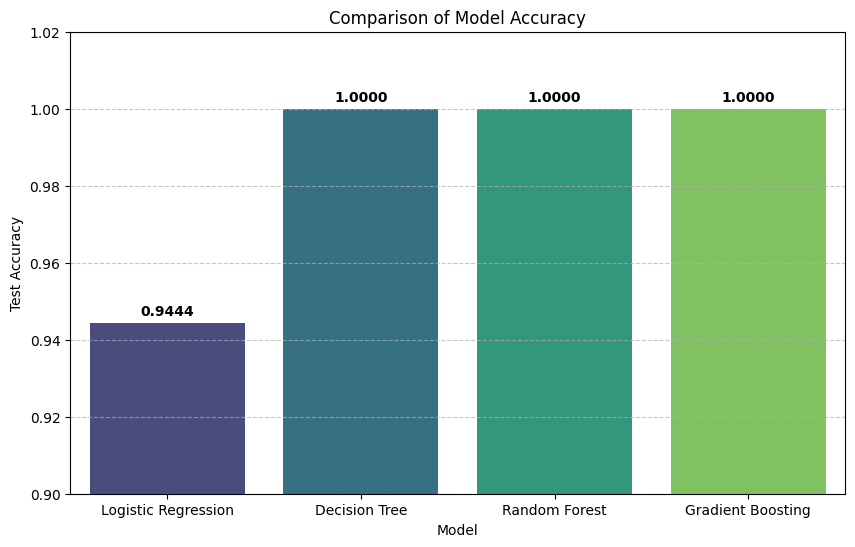

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
model_names = full_comparison_df['Model']
accuracy_scores = full_comparison_df['Test Accuracy']

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')

# Add labels and title
plt.ylim(0.9, 1.02)  # Focus on the high-performance range
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.title('Comparison of Model Accuracy')

# Add the specific accuracy values on top of the bars
for i, score in enumerate(accuracy_scores):
    plt.text(i, score + 0.002, f'{score:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

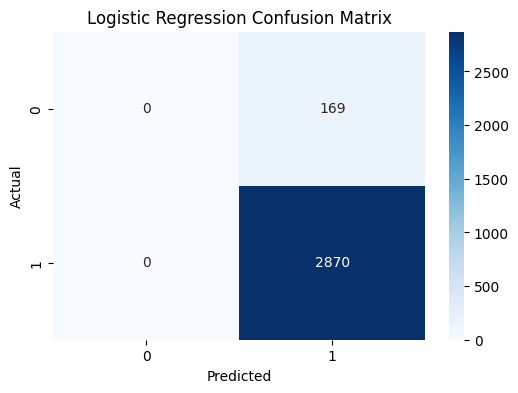

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Save Confusion Matrix for Model 1 (Logistic Regression)
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.savefig('confusion_matrix_model1.png')
plt.show()

In [86]:
%%writefile model_comparison.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Data Preparation
df = pd.read_csv('dataset.csv')
X = df.drop('anomaly', axis=1)
y = df['anomaly']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Model Selection & Training
# Model 1
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Model 2
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 3. Evaluation
print('--- Logistic Regression Report ---')
print(classification_report(y_test, y_pred_lr))

print('\n--- Decision Tree Report ---')
print(classification_report(y_test, y_pred_dt))

# 4. Accuracy Comparison
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')

Writing model_comparison.py


In [43]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

In [44]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

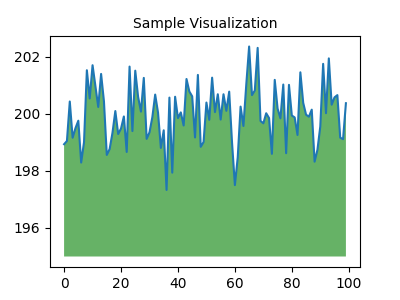

In [45]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)